<a href="https://colab.research.google.com/github/nikinbaidar/NLP-Troll-Detection/blob/main/Troll_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NLP Task: Troll Detection

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Define the project root directory
root = '/content/drive/MyDrive/Colab Notebooks/Troll-Detection/'

import sys
sys.path.append(root)

Import the data.

In [ ]:
import pandas as pd
df = pd.read_csv(root + "impermium_verification_labels.csv")
df.shape

(2235, 5)

So our data has 2235 examples and 5 features.

Let's take a look at the first few examples in our dataframe.

In [ ]:
df.head(10)

,id,Insult,Date,Comment,Usage
0,1,0,20120603163526Z,"""like this if you are a tribe fan""",PrivateTest
1,2,1,20120531215447Z,"""you're idiot.......................""",PrivateTest
2,3,1,20120823164228Z,"""I am a woman Babs, and the only ""war on women...",PrivateTest
3,4,1,20120826010752Z,"""WOW & YOU BENEFITTED SO MANY WINS THIS YEAR F...",PrivateTest
4,5,1,20120602223825Z,"""haha green me red you now loser whos winning ...",PrivateTest
5,6,0,20120603202442Z,"""\nMe and God both hate-faggots.\n\nWhat's the...",PrivateTest
6,7,1,20120603163604Z,"""Oh go kiss the ass of a goat....and you DUMMY...",PrivateTest
7,8,0,20120602223902Z,"""Not a chance Kid, you're wrong.""",PrivateTest
8,9,0,20120528064125Z,"""On Some real Shit FUck LIVE JASMIN!!!""",PrivateTest
9,10,1,20120603071243Z,"""ok but where the hell was it released?you all...",PrivateTest


Print the unique values in the columns `Insult` & `Usage`.

In [ ]:
df["Insult"].unique()

array([0, 1])

In [ ]:
df["Usage"].unique()

array(['PrivateTest'], dtype=object)

So, the column `Insult` has one of two values `0` or `1`. We want our final model to predict how likely a comment is an insult rather than binary `insult`
or `not insult`.

Also, the column `Usage` has only a single unique value 'PrivateTest' which is of no use so let's drop the `Usage` column.

In [ ]:
df.drop("Usage", axis=1, inplace=True)

Also, the column `Date` has nothing to do with the type of comment a user can make so let's drop that too.

In [ ]:
df.drop("Date", axis=1, inplace=True)

In [ ]:
df.head(3)

,id,Insult,Comment
0,1,0,"""like this if you are a tribe fan"""
1,2,1,"""you're idiot......................."""
2,3,1,"""I am a woman Babs, and the only ""war on women..."


Let's keep `id`, `Insult` and `Comment` for now.

In [ ]:
df.shape

(2235, 3)

# Text Cleaning

In [ ]:
text = df["Comment"]
type(text)

pandas.core.series.Series

## Establish a text cleaning pipeline

1. [X] Normalize
1. [X] Parse HTML with `BeautifulSoup`
1. [X] Whitespace characters
1. [X] Underscores
1. [X] Quotation marks
1. [X] Conversion to Lowercase
1. [X] Punctuations
1. [X] Unicode characters :- emoticons, non-english characters
1. [ ] Contraction handling
1. [ ] Other special characters

## Import a custom Py module with NLP utillites

In [ ]:
import nlp_utils
import importlib

importlib.reload(nlp_utils)
textcleaner = nlp_utils.TextCleaner()

Let's take a look at a random example.

In [ ]:
import random
random.seed(42)
random_index = random.randint(0, 2235)

Let's take an initial look at a random comment.

In [ ]:
text = df["Comment"]
original = text
original[random_index]

'"\\xa0Funny how VZ hasn\'t been refining their own oil at all. It\'s always been foreign companies.\\n\\nAnd funny how idiots like you suspect sabotage where none exists."'

This original text will go through a bunch of steps in our text cleaning pipeline.

First, normalize the text viz. includes converting all quoted and escaped literals into equivalent Py values.

In [ ]:
text = text.apply(textcleaner.normalize_literal_string)
normalized = text
normalized[random_index]

"\xa0Funny how VZ hasn't been refining their own oil at all. It's always been foreign companies.\n\nAnd funny how idiots like you suspect sabotage where none exists."

Fix HTML

In [ ]:
from bs4 import BeautifulSoup

text = text.apply(lambda t: BeautifulSoup(t, "html.parser").get_text())
htmlParsed = text
htmlParsed[random_index]

"\xa0Funny how VZ hasn't been refining their own oil at all. It's always been foreign companies.\n\nAnd funny how idiots like you suspect sabotage where none exists."

Fix White Space characters

In [ ]:
text = text.apply(textcleaner.FixWhiteSpace)
whiteSpacedFixed = text
whiteSpacedFixed[random_index]

"Funny how VZ hasn't been refining their own oil at all. It's always been foreign companies. And funny how idiots like you suspect sabotage where none exists."

Remove underscores and minus characters

In [ ]:
text = text.apply(textcleaner.RemoveSymbols)
symbolsRemoved = text
symbolsRemoved[random_index]

"Funny how VZ hasn't been refining their own oil at all. It's always been foreign companies. And funny how idiots like you suspect sabotage where none exists."

Remove `"` and `'` characters entirely.

In [ ]:
text = text.apply(textcleaner.RemoveQuotes)
quotesRemoved = text
quotesRemoved[random_index]

'Funny how VZ hasnt been refining their own oil at all. Its always been foreign companies. And funny how idiots like you suspect sabotage where none exists.'

Conver all characters to lowercase where possible.

In [ ]:
text = text.apply(textcleaner.tolower)
lowercased = text
lowercased[random_index]

'funny how vz hasnt been refining their own oil at all. its always been foreign companies. and funny how idiots like you suspect sabotage where none exists.'

~~Remove~~ Tag punctuation marks to preserve semantics.

In [ ]:
text = text.apply(textcleaner.TokenizePunctuationMarks)
punctuationMarksTokenized = text
punctuationMarksTokenized[random_index]

'funny how vz hasnt been refining their own oil at all. its always been foreign companies. and funny how idiots like you suspect sabotage where none exists.'

Fix dots?

In [ ]:
text = text.apply(textcleaner.FixDots)
dotsFixed = text
dotsFixed[random_index]

'funny how vz hasnt been refining their own oil at all. its always been foreign companies. and funny how idiots like you suspect sabotage where none exists'

Now, we deal with special characters such as unicode characters.

In [ ]:
def is_ascii(text):
    try:
        text.encode("ascii")
        return True
    except UnicodeEncodeError:
        return False

In [ ]:
unicode_encoding_idxs = [idx for idx, t in enumerate(text) if not is_ascii(t)]
len(unicode_encoding_idxs)

26

So, there are 26 examples that contain where unicode characters are present.
Since 26 is a fairly small number, we can choose to drop all these examples from our data.

But first, let's have a peek into each of these examples.

In [ ]:
text[unicode_encoding_idxs]

,Comment
23,não tenho a mínima paciência pra esse tipo de ...
120,"obozonomore—gee, your comments are sure enligh..."
378,"you,both are homosexuals🌈🌈🌈🌈🏩🏩🏩🏩💋💋💋💋"
397,parabens verdão. o palmeiras foi melhor que o ...
399,"heh, no reason to yell. all i did was state th..."
453,se la legge elettorale rimane quella descritta...
461,kein wort über die säuberungsaktionendie seit ...
618,oh du calme on ne va pas te déporter. il faudr...
743,ahora sus abogados presentarán la reclamación ...
1012,you are a strong beautiful mother _X\n hang in...


Most of these seem to be non-english comments.

So, let's replace each of these 26 examples with `np.nan` and we will drop these later.


In [ ]:
print(unicode_encoding_idxs[:3])

[23, 120, 378]


In [ ]:
import numpy as np

text[unicode_encoding_idxs] = np.nan
unicodeCharsRemoved = text
unicodeCharsRemoved[[0, 1, 2, 23, 120, 378]]

,Comment
0,like this if you are a tribe fan
1,youre idiot _SS
2,"i am a woman babs, and the only war on women i..."
23,NaN
120,NaN
378,NaN


Now, let's log all the steps in our pipeline.

In [ ]:
# Clear the logs.txt file it it exists.
logfile = root + "logs.txt"
open(logfile, "w").close()

"""
PIPELINE:
    NORMALIZE -> BeautifulSoup ->
"""

pipeline = {
    "original"                   : original,
    "normalized"                 : normalized,
    "htmlParsed"                 : htmlParsed,
    "whiteSpacedFixed"           : whiteSpacedFixed,
    "symbolsRemoved"             : symbolsRemoved,
    "quotesRemoved"              : quotesRemoved,
    "lower cased"                : lowercased,
    "punctuationMarksTokenized"  : punctuationMarksTokenized,
    "dotsFixed"                  : dotsFixed,
    "unicodeCharRemoved"         : unicodeCharsRemoved
}

SEPARATOR = '-'*100
with open(logfile, "a") as f:
    for index in range(df["Comment"].shape[0]):
        f.write(f"\n- id = {df.loc[index, "id"]}\n")
        entry = "\n\n".join(f"{step}:\n{repr(results[index])}" \
                for step, results in pipeline.items())
        f.write(f"\n{entry}\n\n{SEPARATOR}\n")

Finally, let's replace `df["Comment"]` with our cleaned text.

In [ ]:
type(text)

pandas.core.series.Series

In [ ]:
df["Comment"] = text

In [ ]:
df.head(3)

,id,Insult,Comment
0,1,0,like this if you are a tribe fan
1,2,1,youre idiot _SS
2,3,1,"i am a woman babs, and the only war on women i..."


In [ ]:
df.shape

(2235, 3)

# Exploratory Data Analysis

1. Check the logs.txt file to see the results of text cleaning.

Now, let's drop the examples where the `Comment` column holds empty strings.

In [ ]:
df = df.dropna()

In [ ]:
df.shape

(2209, 3)

In [ ]:
df[20:30]

,id,Insult,Comment
20,21,0,"its a wild wild world, keep your dirty fingers..."
21,22,0,are you about to recapture your swag _Q
22,23,1,no shit _SS\n you must be a genius
24,25,1,are you on roids by chance _Q
25,26,1,you are a disgusting human being
26,27,0,you are well versed when it may be on. must be...
27,28,0,we _Q\n you and the mouse in your pocket _Q
28,29,0,glad you realize this :p kidding
29,30,0,damn _X\n you would rock this so hard _X
30,31,0,in your face cano haters


Notice, when we drop the columns the indexes are preserved. This is normal pandas behaviour. Let's reset these index so it won't cause issues down the road.

In [ ]:
df = df.reset_index(drop=True)
df[20:30]

,id,Insult,Comment
20,21,0,"its a wild wild world, keep your dirty fingers..."
21,22,0,are you about to recapture your swag _Q
22,23,1,no shit _SS\n you must be a genius
23,25,1,are you on roids by chance _Q
24,26,1,you are a disgusting human being
25,27,0,you are well versed when it may be on. must be...
26,28,0,we _Q\n you and the mouse in your pocket _Q
27,29,0,glad you realize this :p kidding
28,30,0,damn _X\n you would rock this so hard _X
29,31,0,in your face cano haters


Separate the Features X and labels y.

In [ ]:
df.head(3)

,id,Insult,Comment
0,1,0,like this if you are a tribe fan
1,2,1,youre idiot _SS
2,3,1,"i am a woman babs, and the only war on women i..."


# Tokenization

In [ ]:
import nltk

In [ ]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('brown')
nltk.download('treebank')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package treebank to /root/nltk_data...
[nltk_data]   Package treebank is already up-to-date!


True

In [ ]:
from nltk import word_tokenize
import re


def SplitAndTokenize(sequence):
    """
    Splits a comment into phrases by delimiters, then tokenizes each phrase.
    e.g. "A quick brown fox\njumps over the lazy dog" becomes
    [['A', 'quick', 'brown', 'fox'], ['jumps', 'over', 'the', 'lazy', 'dog']]
    """
    delimiters = r'[;:\.()\n]'
    phrases = re.split(delimiters, sequence)
    tokens = [word_tokenize(phrase) for phrase in phrases]
    return tokens


def getCleanedAndSplit(value, identifier="id"):
    comment = df[df[identifier] == value]["Comment"]
    for item in comment.iloc[0]:
        print(item)



In [ ]:
split_and_tokenized_comments = df["Comment"].apply(SplitAndTokenize)
df["Comment"] = split_and_tokenized_comments

Our data is cleaned and tokenized at this point, the next step is tagging and categorizing our data i.e. Lingusitc preparation.

# Feature Extraction

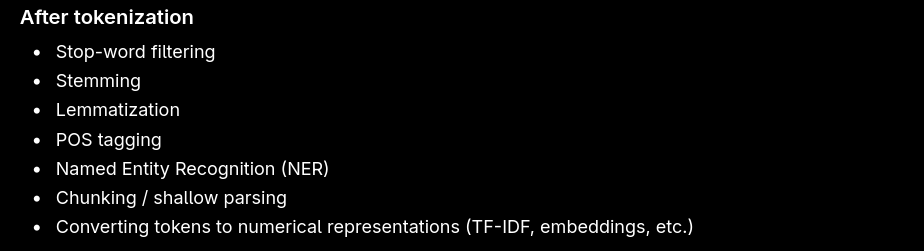

Let's build a words array of all the words in our data.

In [ ]:
import itertools

phrases = itertools.chain.from_iterable(split_and_tokenized_comments)
words = itertools.chain.from_iterable(phrases)
words = list(words)
print(len(words))

44633


## Stop Word Filtering

In [ ]:
from nltk.corpus import stopwords

english_stopwords = set(stopwords.words("english"))
len(english_stopwords)

198

So, there are 198 stopwords. Let's filter our data.

For each comment there can be one or more phrases.

So, the pseudocode for this step is


```
for each phrase in a comment
  remove stop words from the phrase
  return the phrase with no stop words
```

In [ ]:
def RemoveStopWords(sequence):
  return [word for word in sequence if word not in english_stopwords]

In [ ]:
comment_no_stopwords = df["Comment"].apply(lambda phrases:
  [RemoveStopWords(phrase)  for phrase in phrases])

comment_no_stopwords = comment_no_stopwords.apply(lambda x: list(itertools.chain.from_iterable(x)))
df["Comment No Stopwords"] = comment_no_stopwords

In [ ]:
df.head(5)

,id,Insult,Comment,Comment No Stopwords
0,1,0,"[[like, this, if, you, are, a, tribe, fan]]","[like, tribe, fan]"
1,2,1,"[[youre, idiot, _SS]]","[youre, idiot, _SS]"
2,3,1,"[[i, am, a, woman, babs, ,, and, the, only, wa...","[woman, babs, ,, war, women, see, coming, jack..."
3,4,1,"[[wow, &, you, benefitted, so, many, wins, thi...","[wow, &, benefitted, many, wins, year, bat, ni..."
4,5,1,"[[haha, green, me, red, you, now, loser, whos,...","[haha, green, red, loser, whos, winning, moron]"


##  POS Tagging and Cateogrizing Words

In [ ]:
from nltk.corpus import brown, treebank
train_data = brown.tagged_sents() + treebank.tagged_sents()

Let's check the length of our traning data.

In [ ]:
len(train_data)

61254

So, we have 61,254 ~words~ sentences to train our tagger.

In [ ]:
from nltk.tag import UnigramTagger, BigramTagger, TrigramTagger


unigram_tagger = UnigramTagger(train_data)
bigram_tagger = BigramTagger(train_data, backoff=unigram_tagger)
trigram_tagger = TrigramTagger(train_data, backoff=bigram_tagger)

In [ ]:
tagged = comment_no_stopwords.apply(lambda sequence: trigram_tagger.tag(sequence))
df["Tagged"] = tagged

In [ ]:
df.head(3)

,id,Insult,Comment,Comment No Stopwords,Tagged
0,1,0,"[[like, this, if, you, are, a, tribe, fan]]","[like, tribe, fan]","[(like, CS), (tribe, NN), (fan, NN)]"
1,2,1,"[[youre, idiot, _SS]]","[youre, idiot, _SS]","[(youre, None), (idiot, NN), (_SS, None)]"
2,3,1,"[[i, am, a, woman, babs, ,, and, the, only, wa...","[woman, babs, ,, war, women, see, coming, jack...","[(woman, NN), (babs, None), (,, ,), (war, NN),..."


## POS Tags and their Meanings


In [ ]:
tags = list([tag for sequence in tagged for  _, tag in sequence])
unique_tags = set(tags)
print(f"{len(tags)} words tagged with {len(unique_tags)} unique tags.")

25607 words tagged with 73 unique tags.


Let's visiualize the distribution of the tags in our data.

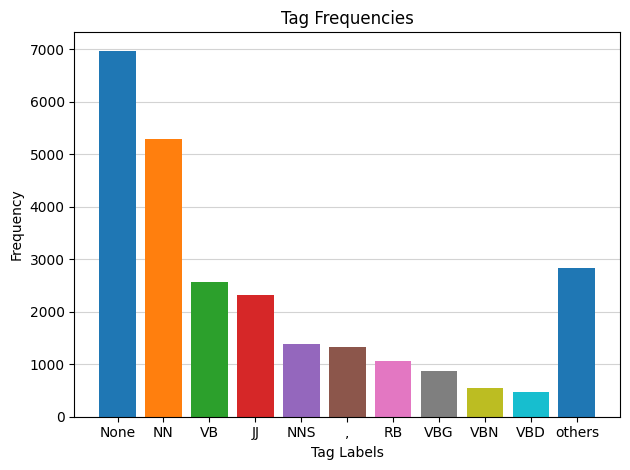

In [ ]:
from collections import Counter
from matplotlib import pyplot as plt

frequency = Counter(str(label) for label in tags)
sorted_freq = dict(sorted(frequency.items(), key=lambda x: x[1], reverse=True))

top10 = dict(list(sorted_freq.items())[:10])
others_sum = sum(list(sorted_freq.values())[10:])
if others_sum > 0:
    top10['others'] = others_sum

plt.bar(x=top10.keys(), height=top10.values(),
        color=plt.cm.tab10.colors[:len(top10)])
plt.xlabel('Tag Labels')
plt.ylabel('Frequency')
plt.title('Tag Frequencies')
plt.tight_layout()
plt.grid(axis='y', color='lightgray')
plt.gca().set_axisbelow(True)
plt.show()

Nouns
- **NN**: Noun, singular or mass (e.g., *table*, *water*)
- **NNS**: Noun, plural (e.g., *tables*, *waters*)
- **NNP**: Proper noun, singular (e.g., *John*, *London*)
- **NNPS**: Proper noun, plural (e.g., *Americans*, *Caesars*)

Verbs
- **VB**: Base form (e.g., *eat*, *go*)
- **VBD**: Past tense (e.g., *ate*, *went*)
- **VBG**: Gerund / present participle (e.g., *eating*, *going*)
- **VBN**: Past participle (e.g., *eaten*, *gone*)
- **VBP**: Non-3rd person singular present (e.g., *eat*, *go*)
- **VBZ**: 3rd person singular present (e.g., *eats*, *goes*)

Adjectives
- **JJ**: Adjective (e.g., *big*, *red*)
- **JJR**: Comparative adjective (e.g., *bigger*, *redder*)
- **JJS**: Superlative adjective (e.g., *biggest*, *reddest*)

Adverbs
- **RB**: Adverb (e.g., *quickly*, *very*)
- **RBR**: Comparative adverb (e.g., *quicker*, *further*)
- **RBS**: Superlative adverb (e.g., *quickest*, *furthest*)

Function Words
- **IN**: Preposition / subordinating conjunction (e.g., *in*, *of*, *before*)
- **DT**: Determiner (e.g., *the*, *a*, *this*)
- **PRP**: Personal pronoun (e.g., *I*, *he*, *she*)
- **PRP$**: Possessive pronoun (e.g., *my*, *his*, *her*)
- **CC**: Coordinating conjunction (e.g., *and*, *but*, *or*)
- **MD**: Modal verb (e.g., *can*, *should*, *will*)
- **TO**: Infinitive marker (e.g., *to* in *to go*)

Numbers & Special Tokens
- **CD**: Cardinal number (e.g., *one*, *two*, *first*)
- **EX**: Existential *there* (e.g., *there is*, *there are*)
- **POS**: Possessive ending (e.g., *'s*)
- **RP**: Particle (e.g., *up*, *off*)

Wh-Words
- **WDT**: Wh-determiner (e.g., *which*, *what*)
- **WP**: Wh-pronoun (e.g., *who*, *whom*)
- **WP$**: Possessive wh-pronoun (e.g., *whose*)
- **WRB**: Wh-adverb (e.g., *where*, *when*, *why*)

Other Tags
- **UH**: Interjection (e.g., *oh*, *yes*, *no*)
- **FW**: Foreign word
- **LS**: List item marker
- **. , ! ?**: Punctuation marks
- **None**: No tag assigned (unknown or unrecognized token)

## Lemmatization

Words -> lemma.

In [ ]:
from nltk import WordNetLemmatizer as wnl
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
lemmatizer = wnl()

In [ ]:
print(lemmatizer.lemmatize('dancing')) # default pos = 'n'
print(lemmatizer.lemmatize('dancing', pos='v'))

dancing
dance


In section [Present POS Tags, their distribution in the data and their Meanings]() we saw our data tagged with 73 unique tags.



In [ ]:
try:
  lemmatizer.lemmatize('dancing', pos='VBG')
except KeyError as e:
  print(f"{e}: {e.__doc__}")

'VBG': Mapping key not found.


The `wnl().lemmaztize` does not recgonize these pos tags generated by our tagger. We need to map each into `nvars` othewise we may get a `KeyError` Exception.



In [ ]:
print(unique_tags)

{'NN-HL', 'PPSS', 'VBN', 'FW-JJ', 'CD-TL', 'AP-HL', 'FW-WDT', 'OD', 'CD-HL', 'FW-PPO', 'JJR', 'BEG', None, 'MD', 'WPS', 'FW-IN+AT-TL', 'AT', 'VBG', 'FW-CC-TL', 'JJ', 'JJT', 'QL', 'JJ-NC', 'VB', 'CS', 'IN', 'RBR', 'FW-NN', 'FW-NNS', '.', 'RP+IN', 'VBD', 'VBZ', 'WRB', 'FW-PPL', 'UH', 'FW-RB', 'WDT', 'NNS-HL', '-NONE-', 'NNP', 'AP', '#', 'NN', 'NR', 'PN', 'PPO', 'RP', 'RB', 'FW-AT', 'FW-IN', '$', 'PP$$', 'CC', '``', 'JJS', 'VB-NC', 'DTX', 'QLP', 'FW-*', 'WP$', ',', 'RBT', 'FW-VB', 'NN-NC', ')', 'VBP', 'CD', 'NNS', 'DT', 'FW', 'ABN', 'FW-IN-TL'}


In [ ]:
def map_pos_tag_to_simplified(tag):
    """
    Maps a given NLTK POS tag to one of five simplified categories:
    'n' (noun), 'v' (verb), 'a' (adjective), 'r' (adverb),
    's' (satellite adjective). Any unmapped tag, including None,
    defaults to 'n'.
    """
    tag_str = str(tag).upper()

    # Nouns and noun-like tags
    if tag_str.startswith(('NN', 'FW-NN', 'PN', 'PPO', 'PP$', 'PPSS',
                           'EX', 'CD', 'WDT', 'WP', 'WPS')):
        return 'n'
    # Verbs and verb-like tags
    elif tag_str.startswith(('VB', 'FW-VB', 'MD')):
        return 'v'
    # Adjectives and adjective-like tags
    elif tag_str.startswith(('JJ', 'FW-JJ')):
        return 'a'
    # Adverbs and adverb-like tags
    elif tag_str.startswith(('RB', 'FW-RB', 'WRB', 'QL')):
        return 'r'
    # Satellite adjectives (AP: attributive adjective, predicative adjective)
    elif tag_str.startswith('AP'):
        return 's'

    # Fallback (punctuation, determiners, conjunctions, etc.)
    # As per the user's rule for 'None' to 'n', these also default to 'n'
    elif tag_str in (',', '.', '!', '?', ';', ':', '(', ')', '``', "''",
                     '#', '$', 'SYM', 'LS', 'FW', 'BEG', 'DTX', 'NR', 'OD',
                     'RP+IN', 'FW-*', 'FW-PPO', 'FW-AT', 'FW-NNS', 'AT', 'CC',
                     'FW-CC-TL', 'FW-IN', 'FW-IN-TL', 'FW-IN+AT-TL', 'IN',
                     'TO', 'RP', 'UH', 'DT', '-NONE-'):
        return 'n'

    # Default for any other unhandled tag, aligning with the 'None' rule
    return 'n'

# Create a dictionary for the mapping of all unique tags observed
pos_tag_simplified_map = {tag: map_pos_tag_to_simplified(tag) for tag in unique_tags}

# Apply the mapping to the 'Tagged' column to create 'Simplified_POS_Tags'
# Each item in 'Tagged' is a list of (word, original_tag) tuples
simplified_tagged_comments = df["Tagged"].apply(lambda tagged_list:
    [(word, pos_tag_simplified_map.get(tag, 'n')) for word, tag in tagged_list])

df["Simplified_POS_Tags"] = simplified_tagged_comments

# Display a sample of the created mapping
print("Mapping of original POS tags to simplified categories (sample of 10):")
for tag, simplified_tag in list(pos_tag_simplified_map.items())[:10]:
    print(f"  '{tag}' -> '{simplified_tag}'")

Mapping of original POS tags to simplified categories (sample of 10):
  'NN-HL' -> 'n'
  'PPSS' -> 'n'
  'VBN' -> 'v'
  'FW-JJ' -> 'a'
  'CD-TL' -> 'n'
  'AP-HL' -> 's'
  'FW-WDT' -> 'n'
  'OD' -> 'n'
  'CD-HL' -> 'n'
  'FW-PPO' -> 'n'


So, now we will use the `(token, pos)` from the `Simplified_POS_Tags` column to
lemmatize our data.

In [ ]:
def lemmatize(sequence):
  return [lemmatizer.lemmatize(token, pos=pos) for token, pos in sequence]

In [ ]:
df['Lemmatized'] = df['Simplified_POS_Tags'].apply(lambda s: lemmatize(s))

In [ ]:
df.head(3)

,id,Insult,Comment,Comment No Stopwords,Tagged,Simplified_POS_Tags,Lemmatized
0,1,0,"[[like, this, if, you, are, a, tribe, fan]]","[like, tribe, fan]","[(like, CS), (tribe, NN), (fan, NN)]","[(like, n), (tribe, n), (fan, n)]","[like, tribe, fan]"
1,2,1,"[[youre, idiot, _SS]]","[youre, idiot, _SS]","[(youre, None), (idiot, NN), (_SS, None)]","[(youre, n), (idiot, n), (_SS, n)]","[youre, idiot, _SS]"
2,3,1,"[[i, am, a, woman, babs, ,, and, the, only, wa...","[woman, babs, ,, war, women, see, coming, jack...","[(woman, NN), (babs, None), (,, ,), (war, NN),...","[(woman, n), (babs, n), (,, n), (war, n), (wom...","[woman, babs, ,, war, woman, see, come, jackaz..."


In [ ]:
df.iloc[[1, 500, 551], [5, 6]]

,Simplified_POS_Tags,Lemmatized
1,"[(youre, n), (idiot, n), (_SS, n)]","[youre, idiot, _SS]"
500,"[(roshan, n), (narayans, n), (father, n), (_Q,...","[roshan, narayans, father, _Q, lol]"
551,"[(apparently, r), (see, v), (nothing, n)]","[apparently, see, nothing]"


## Bagging

Let's run a few vectorizers through a smaller sample.

In [ ]:
sample = df.iloc[0:5, 6]
type(sample)

pandas.core.series.Series

In [ ]:
sample

,Lemmatized
0,"[like, tribe, fan]"
1,"[youre, idiot, _SS]"
2,"[woman, babs, ,, war, woman, see, come, jackaz..."
3,"[wow, &, benefitted, many, win, year, bat, nic..."
4,"[haha, green, red, loser, who, win, moron]"


In [ ]:
sample_distinct_words = list({ word for sequence in sample for word in sequence })
len(sample_distinct_words)

37

In [ ]:
def create_bag_of_words(sequence, distinct_words):
  """
  Term Frequency
  """
  bag_of_words = [sequence.count(word) for word in distinct_words]
  return bag_of_words

sample_bag_of_words = sample.apply(lambda sequence: create_bag_of_words(sequence, sample_distinct_words))

In [ ]:
sample_bag_of_words.name = 'Bag of words'
sample_bag_of_words

,Bag of words
0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,"[1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, ..."
3,"[0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, ..."
4,"[0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [ ]:
distinct_words = list({w for sequence in df['Lemmatized'] for w in sequence})
bag_of_words = df['Lemmatized'].apply(lambda s: create_bag_of_words(s, distinct_words))

In [ ]:
print(df['Lemmatized'].iloc[2])

['woman', 'babs', ',', 'war', 'woman', 'see', 'come', 'jackazzes', 'like', 'dont', 'need', 'protection', 'ignorant', 'rhetoric', 'masquerade', 'represent', 'best', 'interest']


In [ ]:
# How many times does 'woman' appear in the third sequence.
distinct_words.index('woman')

394

In [ ]:
print(bag_of_words.iloc[2][504])

0


In [ ]:
df['Bag of words'] = bag_of_words
df.head(3)

,id,Insult,Comment,Comment No Stopwords,Tagged,Simplified_POS_Tags,Lemmatized,Bag of words
0,1,0,"[[like, this, if, you, are, a, tribe, fan]]","[like, tribe, fan]","[(like, CS), (tribe, NN), (fan, NN)]","[(like, n), (tribe, n), (fan, n)]","[like, tribe, fan]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,2,1,"[[youre, idiot, _SS]]","[youre, idiot, _SS]","[(youre, None), (idiot, NN), (_SS, None)]","[(youre, n), (idiot, n), (_SS, n)]","[youre, idiot, _SS]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,3,1,"[[i, am, a, woman, babs, ,, and, the, only, wa...","[woman, babs, ,, war, women, see, coming, jack...","[(woman, NN), (babs, None), (,, ,), (war, NN),...","[(woman, n), (babs, n), (,, n), (war, n), (wom...","[woman, babs, ,, war, woman, see, come, jackaz...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


This cooncludes the pre-processing of our text data.

# Embedding

## Term Frequency-Inverse Document Frequency

Let's generate embeddings for our data.

For this we'll use TF-IDF

In [ ]:
df.shape

(2209, 8)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(analyzer='word',
                             lowercase=False,
                             tokenizer=None,
                             preprocessor=None,
                             stop_words=None,
                             max_features=5000)

In [ ]:
# Transform the linguistic data into numerical representations
# For each example, get 5000 features
documents = df['Lemmatized'].apply(lambda sequence: ' '.join(sequence))
vectorizer = vectorizer.fit(documents)
training_features = vectorizer.transform(documents)
type(training_features)

scipy.sparse._csr.csr_matrix

In [ ]:
X = training_features.toarray()
type(X), X.shape

(numpy.ndarray, (2209, 5000))

We have 2209 examples and 5000 features.


These 5000 features are the "most important" in regard to "TF-IDF"

In [ ]:
y = df['Insult'].values
type(y), y.shape

(numpy.ndarray, (2209,))

Instead of a binary classifier that produces `insult` or `not insult`, rather a
continous prediction that predicts % insult is desired.

So, let's train a regressor model.

# Train a regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest
trollspotter = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
)

trollspotter.fit(X_train, y_train)

# Predict
y_pred = trollspotter.predict(X_test)


# Model Assesment

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)
print("Random Forest benchmark AUC score, 100 estimators")
print(roc_auc)


Random Forest benchmark AUC score, 100 estimators
0.7667076292882744


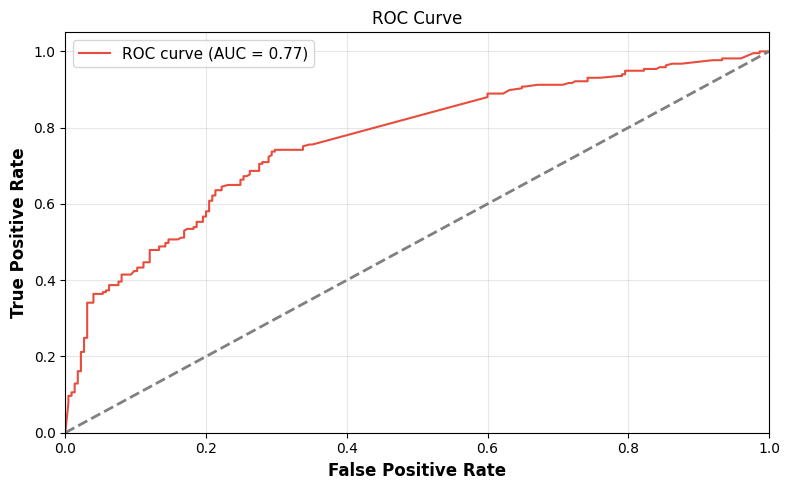

In [ ]:
# Plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(fpr, tpr, color='#e74c3c', label=f'ROC curve (AUC = {roc_auc:.2f})')
ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')

ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.05)
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve')
ax.legend(loc='best', fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Test the baseline

In [ ]:
from nltk import WordNetLemmatizer as wnl

def get_troll_score(user_input, model, vectorizer):
  lemmatizer = wnl()
  lemmatized = [lemmatizer.lemmatize(word.lower()) for word in user_input.split()]
  # Vectorize using the SAME vectorizer
  user_vector = vectorizer.transform([' '.join(lemmatized)])
  score = model.predict(user_vector)[0]

  return round(score, 2)

In [ ]:
tests = [
    # Non-toxic
    "thank you for your help",
    "have a wonderful weekend",
    "I disagree with your opinion",
    "this movie was fantastic",

    # Mild toxicity
    "you're annoying",
    "that was a dumb thing to do",
    "stop acting like an idiot",
    "you're being ridiculous",

    # Strong toxicity
    "you're a complete moron",
    "nobody likes you",
    "you're pathetic",
    "go away, loser",

    # Profanity directed at a person
    "you are an asshole",
    "you're a fucking idiot",
    "what the hell is wrong with you",
    "you're full of shit",

    # Profanity not directed at a person
    "this code is fucking broken",
    "damn, I forgot my keys",
    "that exam was bullshit",
    "holy shit, that was close",

    # Obfuscated profanity
    "you are a$$",
    "f u",
    "you're a b1tch",
    "what a sh1tty idea",
    "you're an id10t",

    # Sarcasm
    "wow, you're a genius",
    "great job breaking everything",
    "thanks for being so helpful",

    # Threatening / aggressive
    "I hate you",
    "get lost",
    "shut up",
    "nobody asked for your opinion"
]

In [ ]:
print(f" {'example':<35} {'score'}")
print("-"*45)
for example in tests:
  score = get_troll_score(example, trollspotter, vectorizer)
  print(f"'{example:<35}| {score}")

 example                             score
---------------------------------------------
'thank you for your help            | 0.38
'have a wonderful weekend           | 0.38
'I disagree with your opinion       | 0.38
'this movie was fantastic           | 0.38
'you're annoying                    | 0.38
'that was a dumb thing to do        | 0.99
'stop acting like an idiot          | 0.91
'you're being ridiculous            | 0.38
'you're a complete moron            | 1.0
'nobody likes you                   | 0.41
'you're pathetic                    | 0.72
'go away, loser                     | 0.47
'you are an asshole                 | 0.39
'you're a fucking idiot             | 1.0
'what the hell is wrong with you    | 0.38
'you're full of shit                | 0.35
'this code is fucking broken        | 0.38
'damn, I forgot my keys             | 0.38
'that exam was bullshit             | 0.38
'holy shit, that was close          | 0.34
'you are a$$                        | 0.38
'f u      

 The scoring seems to capture direct insults well, but struggles with context and intent. The high baseline (0.38) might be inflating all scores, making it harder to meaningfully differentiate lower-level toxicity from higher-level attacks.